In [2]:
%pip install yfinance

  Using cached yfinance-1.7.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached curl_cffi-0.16.3-cp310-abi3-win_amd64.whl.metadata (17 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.5.1-py3-none-any.whl.metadata (10 kB)
Using cached yfinance-1.7.0-py3-none-any.whl (149 kB)
Using cached curl_cffi-0.16.3-cp310-abi3-win_amd64.whl (2.0 MB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.0 MB 3.1 MB/s eta 0:00:01
   --------------- ------------------------ 1.6/4.0 MB 2.9 MB/s eta 0:00:01
   ----------------------- ---------------- 2.4/4.0 MB 3.2 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.4 MB/s  0:00:01
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.5.1-py3-none-any.

In [10]:
import yfinance as yf
import pandas as pd

ticker = "TEMPSENS.NS"
df = yf.download(ticker, start="2025-01-01", end="2026-09-11")
df.columns = df.columns.get_level_values(0)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-08-28,586.650024,634.849976,551.150024,634.000000,51084119
2026-08-31,563.599976,585.000000,557.099976,579.000000,8261866
2026-09-01,539.049988,574.799988,534.700012,560.200012,8343086
2026-09-02,566.299988,589.000000,535.049988,536.000000,15878807
2026-09-03,568.549988,584.950012,556.049988,577.500000,5154377


In [11]:
reference_high = df["High"].iloc[:3].max()
reference_high

np.float64(634.8499755859375)

In [12]:
lowest_after_high = df["Low"].iloc[3:].min()
drawdown_pct = (reference_high - lowest_after_high) / reference_high * 100

current_price = df["Close"].iloc[-1]
recovery_pct = current_price / reference_high * 100

drawdown_pct, recovery_pct

(np.float64(15.720247559410854), np.float64(91.56493819763566))

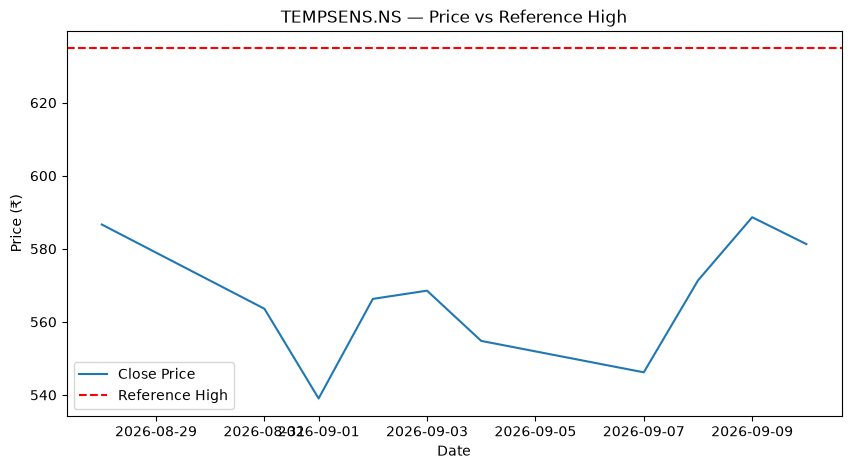

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Close"], label="Close Price")
plt.axhline(y=reference_high, color="red", linestyle="--", label="Reference High")

plt.title(f"{ticker} — Price vs Reference High")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.show()

In [35]:
def analyze_ipo(ticker, start="2025-01-01", end="2026-09-11", reference_days=5, min_days_after=5):
    try:
        data = yf.download(ticker, start=start, end=end, progress=False)
        if data.empty:
            return {"ticker": ticker, "error": "No data found"}

        data.columns = data.columns.get_level_values(0)

        if len(data) < reference_days + min_days_after:
            return {"ticker": ticker, "error": "Too new — not enough post-reference data yet"}

        ref_high = data["High"].iloc[:reference_days].max()
        lowest_after = data["Low"].iloc[reference_days:].min()
        drawdown = (ref_high - lowest_after) / ref_high * 100

        current_price = data["Close"].iloc[-1]
        recovery = current_price / ref_high * 100
        retracement = (current_price - lowest_after) / (ref_high - lowest_after) * 100

        return {
            "ticker": ticker,
            "reference_high": round(ref_high, 2),
            "lowest_after_high": round(lowest_after, 2),
            "drawdown_pct": round(drawdown, 2),
            "current_price": round(current_price, 2),
            "recovery_pct": round(recovery, 2),
            "retracement_pct": round(retracement, 2),
        }
    except Exception as e:
        return {"ticker": ticker, "error": str(e)}

In [27]:
analyze_ipo("TEMPSENS.NS")

{'ticker': 'TEMPSENS.NS',
 'reference_high': np.float64(634.85),
 'lowest_after_high': np.float64(537.35),
 'drawdown_pct': np.float64(15.36),
 'current_price': np.float64(581.3),
 'recovery_pct': np.float64(91.56)}

In [28]:
tickers = ["TEMPSENS.NS", "HONASA.NS", "CELLO.NS", "IREDA.NS", "JIOFIN.NS"]

results = [analyze_ipo(t) for t in tickers]
results_df = pd.DataFrame(results)
results_df

,ticker,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct
0,TEMPSENS.NS,634.85,537.35,15.36,581.30,91.56
1,HONASA.NS,254.86,196.29,22.98,475.65,186.63
2,CELLO.NS,776.59,335.12,56.85,338.90,43.64
3,IREDA.NS,231.51,107.36,53.63,112.57,48.62
4,JIOFIN.NS,309.69,197.88,36.10,230.25,74.35


In [39]:
tickers = [
    "TEMPSENS.NS", "HONASA.NS", "CELLO.NS", "IREDA.NS", "JIOFIN.NS",
    "GROWW.NS", "PWL.NS", "URBANCO.NS",
    "ARDEE.NS", "BLEL.NS", "SHANKESH.NS", "TURTLEMINT.NS",
    "LGEINDIA.NS", "SBIFUNDS.NS",
    "PRIORITY.NS", "SHIPROCKET.NS", "LOTUSDEV.NS", "KUSUMGAR.NS",
    "SAILIFE.NS", "WAAREEENER.NS", "VMM.NS"
]

results_df_5day = pd.DataFrame([analyze_ipo(t) for t in tickers])
results_df_5day

,ticker,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct,retracement_pct,error
0,TEMPSENS.NS,634.85,537.35,15.36,581.30,91.56,45.08,NaN
1,HONASA.NS,254.86,196.29,22.98,475.65,186.63,476.93,NaN
2,CELLO.NS,776.59,335.12,56.85,338.90,43.64,0.86,NaN
3,IREDA.NS,231.51,107.36,53.63,112.57,48.62,4.20,NaN
4,JIOFIN.NS,309.69,197.88,36.10,230.25,74.35,28.95,NaN
5,GROWW.NS,193.80,142.11,26.67,195.84,101.05,103.95,NaN
6,PWL.NS,161.99,77.72,52.02,126.73,78.23,58.16,NaN
7,URBANCO.NS,201.18,100.70,49.95,164.56,81.80,63.55,NaN
8,ARDEE.NS,73.19,52.39,28.42,52.62,71.90,1.11,NaN
9,BLEL.NS,548.00,431.10,21.33,441.60,80.58,8.98,NaN


In [40]:
results_df_5day.to_csv("../data/ipo_drawdown_recovery.csv", index=False)

In [49]:
def check_signal(ticker, min_drawdown=15, min_retracement=65, max_retracement=110, reference_days=5):
    result = analyze_ipo(ticker, reference_days=reference_days)

    if "error" in result and result.get("drawdown_pct") is None:
        result["signal"] = "Not evaluated"
        result["reason"] = result["error"]
        return result

    drawdown_ok = result["drawdown_pct"] >= min_drawdown
    retracement_ok = min_retracement <= result["retracement_pct"] <= max_retracement

    if drawdown_ok and retracement_ok:
        result["signal"] = "SETUP DETECTED"
        result["reason"] = f"Drawdown {result['drawdown_pct']}% >= {min_drawdown}%, Retracement {result['retracement_pct']}% in [{min_retracement}-{max_retracement}]%"
    else:
        result["signal"] = "No signal"
        reasons = []
        if not drawdown_ok:
            reasons.append(f"Drawdown too small ({result['drawdown_pct']}% < {min_drawdown}%)")
        if not retracement_ok:
            if result["retracement_pct"] < min_retracement:
                reasons.append(f"Retracement too weak ({result['retracement_pct']}% < {min_retracement}%)")
            else:
                reasons.append(f"Already overshot old high ({result['retracement_pct']}% > {max_retracement}%) — past the entry window")
        result["reason"] = "; ".join(reasons)

    return result

In [50]:
check_signal("TEMPSENS.NS")

{'ticker': 'TEMPSENS.NS',
 'reference_high': np.float64(634.85),
 'lowest_after_high': np.float64(537.35),
 'drawdown_pct': np.float64(15.36),
 'current_price': np.float64(581.3),
 'recovery_pct': np.float64(91.56),
 'retracement_pct': np.float64(45.08),
 'signal': 'No signal',
 'reason': 'Retracement too weak (45.08% < 65%)'}

In [51]:
signal_results = [check_signal(t) for t in tickers]
signal_df = pd.DataFrame(signal_results)
signal_df

,ticker,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct,retracement_pct,signal,reason,error
0,TEMPSENS.NS,634.85,537.35,15.36,581.30,91.56,45.08,No signal,Retracement too weak (45.08% < 65%),NaN
1,HONASA.NS,254.86,196.29,22.98,475.65,186.63,476.93,No signal,Already overshot old high (476.93% > 110%) — p...,NaN
2,CELLO.NS,776.59,335.12,56.85,338.90,43.64,0.86,No signal,Retracement too weak (0.86% < 65%),NaN
3,IREDA.NS,231.51,107.36,53.63,112.57,48.62,4.20,No signal,Retracement too weak (4.2% < 65%),NaN
4,JIOFIN.NS,309.69,197.88,36.10,230.25,74.35,28.95,No signal,Retracement too weak (28.95% < 65%),NaN
5,GROWW.NS,193.80,142.11,26.67,195.84,101.05,103.95,SETUP DETECTED,"Drawdown 26.67% >= 15%, Retracement 103.95% in...",NaN
6,PWL.NS,161.99,77.72,52.02,126.73,78.23,58.16,No signal,Retracement too weak (58.16% < 65%),NaN
7,URBANCO.NS,201.18,100.70,49.95,164.56,81.80,63.55,No signal,Retracement too weak (63.55% < 65%),NaN
8,ARDEE.NS,73.19,52.39,28.42,52.62,71.90,1.11,No signal,Retracement too weak (1.11% < 65%),NaN
9,BLEL.NS,548.00,431.10,21.33,441.60,80.58,8.98,No signal,Retracement too weak (8.98% < 65%),NaN


In [52]:
signal_df.to_csv("../data/ipo_signals.csv", index=False)

In [53]:
ticker = "LGEINDIA.NS"
data = yf.download(ticker, start="2025-01-01", end="2026-09-11", progress=False)
data.columns = data.columns.get_level_values(0)

reference_days = 5
ref_high = data["High"].iloc[:reference_days].max()
ref_high

np.float64(1749.0)

In [54]:
signal_date = None

for i in range(reference_days, len(data)):
    # Only look at data UP TO today (day i) — nothing after
    data_so_far = data.iloc[:i+1]
    
    lowest_so_far = data_so_far["Low"].iloc[reference_days:].min()
    drawdown_so_far = (ref_high - lowest_so_far) / ref_high * 100
    
    price_today = data_so_far["Close"].iloc[-1]
    retracement_so_far = (price_today - lowest_so_far) / (ref_high - lowest_so_far) * 100
    
    if drawdown_so_far >= 15 and 65 <= retracement_so_far <= 110:
        signal_date = data_so_far.index[-1]
        signal_price = price_today
        break

signal_date, signal_price

(Timestamp('2026-04-20 00:00:00'), np.float64(1594.0999755859375))

In [63]:
holding_period = 60  # trading days after signal

# Find the position of the signal date in the data
signal_position = data.index.get_loc(signal_date)

# Get the price 30 trading days later
exit_position = signal_position + holding_period

if exit_position < len(data):
    exit_price = data["Close"].iloc[exit_position]
    exit_date = data.index[exit_position]
    return_pct = (exit_price - signal_price) / signal_price * 100
else:
    exit_price = None
    exit_date = None
    return_pct = None

signal_date, signal_price, exit_date, exit_price, return_pct

(Timestamp('2026-04-20 00:00:00'),
 np.float64(1594.0999755859375),
 Timestamp('2026-07-13 00:00:00'),
 np.float64(1543.5),
 np.float64(-3.1742033975841855))

In [64]:
def backtest_signal(ticker, reference_days=5, min_drawdown=15, min_retracement=65, max_retracement=110, holding_period=60, start="2025-01-01", end="2026-09-11"):
    data = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty:
        return {"ticker": ticker, "error": "No data found"}
    data.columns = data.columns.get_level_values(0)

    if len(data) < reference_days + 1:
        return {"ticker": ticker, "error": "Not enough data"}

    ref_high = data["High"].iloc[:reference_days].max()

    signal_date = None
    signal_price = None

    # Walk forward day by day, using only data available up to that point
    for i in range(reference_days, len(data)):
        data_so_far = data.iloc[:i+1]
        lowest_so_far = data_so_far["Low"].iloc[reference_days:].min()
        drawdown_so_far = (ref_high - lowest_so_far) / ref_high * 100
        price_today = data_so_far["Close"].iloc[-1]
        retracement_so_far = (price_today - lowest_so_far) / (ref_high - lowest_so_far) * 100

        if drawdown_so_far >= min_drawdown and min_retracement <= retracement_so_far <= max_retracement:
            signal_date = data_so_far.index[-1]
            signal_price = price_today
            signal_position = i
            break

    if signal_date is None:
        return {"ticker": ticker, "error": "No signal ever triggered in this period"}

    exit_position = signal_position + holding_period
    if exit_position >= len(data):
        return {"ticker": ticker, "signal_date": signal_date, "signal_price": round(signal_price, 2),
                "error": "Not enough days after signal to complete holding period yet"}

    exit_price = data["Close"].iloc[exit_position]
    exit_date = data.index[exit_position]
    return_pct = (exit_price - signal_price) / signal_price * 100

    return {
        "ticker": ticker,
        "signal_date": signal_date.date(),
        "signal_price": round(signal_price, 2),
        "exit_date": exit_date.date(),
        "exit_price": round(exit_price, 2),
        "return_pct": round(return_pct, 2),
    }

In [65]:
signaled_tickers = ["GROWW.NS", "LGEINDIA.NS", "LOTUSDEV.NS", "WAAREEENER.NS"]

backtest_results = [backtest_signal(t) for t in signaled_tickers]
backtest_df = pd.DataFrame(backtest_results)
backtest_df

,ticker,signal_date,signal_price,exit_date,exit_price,return_pct,error
0,GROWW.NS,2026-01-30,177.04,2026-05-01,214.99,21.44,NaN
1,LGEINDIA.NS,2026-04-20,1594.10,2026-07-13,1543.50,-3.17,NaN
2,LOTUSDEV.NS,2026-07-24 00:00:00,180.13,NaN,NaN,NaN,Not enough days after signal to complete holdi...
3,WAAREEENER.NS,2025-04-22,2612.38,2025-07-16,3286.07,25.79,NaN


In [66]:
backtest_df.to_csv("../data/backtest_results.csv", index=False)

In [67]:
new_tickers = [
    "ICICIPRUAMC.NS", "NEPHRO.NS", "CORONA.NS", "WAKEFIT.NS", "VIDYAWIRES.NS",
    "MEESHO.NS", "AEQUS.NS", "SUDEEPPHARMA.NS", "EXCELSOFT.NS", "CAPILLARY.NS",
    "TENNECO.NS", "PWL.NS", "EMMVEE.NS", "PINELABS.NS", "LENSKART.NS",
    "STUDDS.NS", "ORKLA.NS", "MIDWEST.NS", "CANARAHSBC.NS", "RUBICON.NS",
    "CANARAROBECO.NS", "TATACAPITAL.NS", "WEWORKINDIA.NS", "MOBIKWIK.NS",
    "IKS.NS", "TRANSRAILLIGHTING.NS", "CARRAROINDIA.NS", "UNIMECH.NS", "VENTIVE.NS"
]

new_results = [analyze_ipo(t) for t in new_tickers]
new_results_df = pd.DataFrame(new_results)
new_results_df

$ICICIPRUAMC.NS: possibly delisted; no timezone found

1 Failed download:
['ICICIPRUAMC.NS']: possibly delisted; no timezone found
$NEPHRO.NS: possibly delisted; no timezone found

1 Failed download:
['NEPHRO.NS']: possibly delisted; no timezone found
$SUDEEPPHARMA.NS: possibly delisted; no timezone found

1 Failed download:
['SUDEEPPHARMA.NS']: possibly delisted; no timezone found
$TENNECO.NS: possibly delisted; no timezone found

1 Failed download:
['TENNECO.NS']: possibly delisted; no timezone found
$ORKLA.NS: possibly delisted; no timezone found

1 Failed download:
['ORKLA.NS']: possibly delisted; no timezone found
$MIDWEST.NS: possibly delisted; no timezone found

1 Failed download:
['MIDWEST.NS']: possibly delisted; no timezone found
$CANARAHSBC.NS: possibly delisted; no timezone found

1 Failed download:
['CANARAHSBC.NS']: possibly delisted; no timezone found
$CANARAROBECO.NS: possibly delisted; no timezone found

1 Failed download:
['CANARAROBECO.NS']: possibly delisted; no tim

,ticker,error,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct,retracement_pct
0,ICICIPRUAMC.NS,No data found,NaN,NaN,NaN,NaN,NaN,NaN
1,NEPHRO.NS,No data found,NaN,NaN,NaN,NaN,NaN,NaN
2,CORONA.NS,NaN,1489.64,1329.32,10.76,2200.80,147.74,543.58
3,WAKEFIT.NS,NaN,203.50,111.40,45.26,152.44,74.91,44.56
4,VIDYAWIRES.NS,NaN,58.45,44.06,24.62,90.21,154.34,320.71
5,MEESHO.NS,NaN,193.44,125.56,35.09,217.91,112.65,136.05
6,AEQUS.NS,NaN,160.65,113.30,29.47,229.96,143.14,246.38
7,SUDEEPPHARMA.NS,No data found,NaN,NaN,NaN,NaN,NaN,NaN
8,EXCELSOFT.NS,NaN,142.59,66.40,53.43,80.08,56.16,17.96
9,CAPILLARY.NS,NaN,798.95,438.15,45.16,459.90,57.56,6.03


In [68]:
combined_tickers = tickers + [
    "CORONA.NS", "WAKEFIT.NS", "VIDYAWIRES.NS", "MEESHO.NS", "AEQUS.NS",
    "EXCELSOFT.NS", "CAPILLARY.NS", "EMMVEE.NS", "PINELABS.NS", "LENSKART.NS",
    "STUDDS.NS", "RUBICON.NS", "MOBIKWIK.NS", "IKS.NS", "UNIMECH.NS", "VENTIVE.NS"
]

all_signals = [check_signal(t) for t in combined_tickers]
all_signals_df = pd.DataFrame(all_signals)
all_signals_df[all_signals_df["signal"] == "SETUP DETECTED"]

,ticker,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct,retracement_pct,signal,reason,error
5,GROWW.NS,193.80,142.11,26.67,195.84,101.05,103.95,SETUP DETECTED,"Drawdown 26.67% >= 15%, Retracement 103.95% in...",NaN
12,LGEINDIA.NS,1749.00,1304.10,25.44,1650.00,94.34,77.75,SETUP DETECTED,"Drawdown 25.44% >= 15%, Retracement 77.75% in ...",NaN
16,LOTUSDEV.NS,218.17,102.05,53.22,207.58,95.14,90.88,SETUP DETECTED,"Drawdown 53.22% >= 15%, Retracement 90.88% in ...",NaN
19,WAAREEENER.NS,2902.09,1860.49,35.89,2546.00,87.73,65.81,SETUP DETECTED,"Drawdown 35.89% >= 15%, Retracement 65.81% in ...",NaN
34,IKS.NS,1983.85,1236.80,37.66,1783.70,89.91,73.21,SETUP DETECTED,"Drawdown 37.66% >= 15%, Retracement 73.21% in ...",NaN
35,UNIMECH.NS,1523.75,695.00,54.39,1568.10,102.91,105.35,SETUP DETECTED,"Drawdown 54.39% >= 15%, Retracement 105.35% in...",NaN


In [70]:
signaled_tickers = ["GROWW.NS", "LGEINDIA.NS", "LOTUSDEV.NS", "WAAREEENER.NS", "IKS.NS", "UNIMECH.NS"]

backtest_results = [backtest_signal(t) for t in signaled_tickers]
backtest_df = pd.DataFrame(backtest_results)
backtest_df

,ticker,signal_date,signal_price,exit_date,exit_price,return_pct,error
0,GROWW.NS,2026-01-30,177.04,2026-05-01,214.99,21.44,NaN
1,LGEINDIA.NS,2026-04-20,1594.10,2026-07-13,1543.50,-3.17,NaN
2,LOTUSDEV.NS,2026-07-24 00:00:00,180.13,NaN,NaN,NaN,Not enough days after signal to complete holdi...
3,WAAREEENER.NS,2025-04-22,2612.38,2025-07-16,3286.07,25.79,NaN
4,IKS.NS,2025-02-21,1843.50,2025-05-27,1571.50,-14.75,NaN
5,UNIMECH.NS,2025-05-29,1297.45,2025-08-22,1082.30,-16.58,NaN


In [71]:
all_signals_hightouch = [check_signal(t, min_retracement=95, max_retracement=130) for t in combined_tickers]
all_signals_hightouch_df = pd.DataFrame(all_signals_hightouch)
all_signals_hightouch_df[all_signals_hightouch_df["signal"] == "SETUP DETECTED"]

,ticker,reference_high,lowest_after_high,drawdown_pct,current_price,recovery_pct,retracement_pct,signal,reason,error
5,GROWW.NS,193.80,142.11,26.67,195.84,101.05,103.95,SETUP DETECTED,"Drawdown 26.67% >= 15%, Retracement 103.95% in...",NaN
35,UNIMECH.NS,1523.75,695.00,54.39,1568.10,102.91,105.35,SETUP DETECTED,"Drawdown 54.39% >= 15%, Retracement 105.35% in...",NaN


In [73]:
hightouch_tickers = ["GROWW.NS", "UNIMECH.NS"]

backtest_hightouch = [
    backtest_signal(t, min_retracement=95, max_retracement=130) 
    for t in hightouch_tickers
]
backtest_hightouch_df = pd.DataFrame(backtest_hightouch)
backtest_hightouch_df

,ticker,signal_date,signal_price,exit_date,exit_price,return_pct,error
0,GROWW.NS,2026-04-10,193.7,2026-07-06,200.17,3.34,NaN
1,UNIMECH.NS,2026-08-14 00:00:00,1522.6,NaN,NaN,NaN,Not enough days after signal to complete holdi...


In [74]:
def max_pullback(ticker, start="2025-01-01", end="2026-09-11"):
    data = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty:
        return {"ticker": ticker, "error": "No data found"}
    data.columns = data.columns.get_level_values(0)

    running_peak = data["High"].cummax()
    daily_pullback = (running_peak - data["Low"]) / running_peak * 100
    worst_pullback = daily_pullback.max()

    return {
        "ticker": ticker,
        "worst_pullback_pct": round(worst_pullback, 2),
        "current_price": round(data["Close"].iloc[-1], 2),
        "all_time_high": round(data["High"].max(), 2),
    }

In [75]:
max_pullback("GROWW.NS")

{'ticker': 'GROWW.NS',
 'worst_pullback_pct': np.float64(26.67),
 'current_price': np.float64(195.84),
 'all_time_high': np.float64(227.2)}

In [76]:
max_pullback("CELLO.NS")

{'ticker': 'CELLO.NS',
 'worst_pullback_pct': np.float64(56.85),
 'current_price': np.float64(338.9),
 'all_time_high': np.float64(776.59)}

In [77]:
pullback_results = [max_pullback(t) for t in tickers]
pullback_df = pd.DataFrame(pullback_results)
pullback_df.sort_values("worst_pullback_pct")

,ticker,worst_pullback_pct,current_price,all_time_high
14,PRIORITY.NS,12.24,226.92,245.00
13,SBIFUNDS.NS,14.15,551.00,624.95
0,TEMPSENS.NS,15.78,581.30,634.85
17,KUSUMGAR.NS,16.12,566.00,659.50
18,SAILIFE.NS,20.85,1591.10,1697.00
15,SHIPROCKET.NS,20.97,129.17,156.90
9,BLEL.NS,21.33,441.60,548.00
10,SHANKESH.NS,21.40,98.41,111.00
12,LGEINDIA.NS,25.44,1650.00,1755.00
1,HONASA.NS,25.67,475.65,506.65


In [78]:
pullback_df["pct_of_ath"] = round(pullback_df["current_price"] / pullback_df["all_time_high"] * 100, 2)
pullback_df.sort_values("worst_pullback_pct")

,ticker,worst_pullback_pct,current_price,all_time_high,pct_of_ath
14,PRIORITY.NS,12.24,226.92,245.00,92.62
13,SBIFUNDS.NS,14.15,551.00,624.95,88.17
0,TEMPSENS.NS,15.78,581.30,634.85,91.56
17,KUSUMGAR.NS,16.12,566.00,659.50,85.82
18,SAILIFE.NS,20.85,1591.10,1697.00,93.76
15,SHIPROCKET.NS,20.97,129.17,156.90,82.33
9,BLEL.NS,21.33,441.60,548.00,80.58
10,SHANKESH.NS,21.40,98.41,111.00,88.66
12,LGEINDIA.NS,25.44,1650.00,1755.00,94.02
1,HONASA.NS,25.67,475.65,506.65,93.88


In [79]:
def days_since_ath(ticker, start="2025-01-01", end="2026-09-11"):
    data = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty:
        return {"ticker": ticker, "error": "No data found"}
    data.columns = data.columns.get_level_values(0)

    ath_date = data["High"].idxmax()
    last_date = data.index[-1]
    days_since = (last_date - ath_date).days

    return {"ticker": ticker, "ath_date": ath_date.date(), "days_since_ath": days_since}

In [80]:
days_since_ath("GROWW.NS"), days_since_ath("TEMPSENS.NS")

({'ticker': 'GROWW.NS',
  'ath_date': datetime.date(2026, 4, 29),
  'days_since_ath': 134},
 {'ticker': 'TEMPSENS.NS',
  'ath_date': datetime.date(2026, 8, 28),
  'days_since_ath': 13})

In [81]:
max_pullback("ANGELONE.NS")

{'ticker': 'ANGELONE.NS',
 'worst_pullback_pct': np.float64(36.04),
 'current_price': np.float64(297.3),
 'all_time_high': np.float64(359.34)}

In [82]:
days_since_ath("ANGELONE.NS")

{'ticker': 'ANGELONE.NS',
 'ath_date': datetime.date(2026, 6, 19),
 'days_since_ath': 83}

In [83]:
def check_breakout(ticker, lookback_days=20, volume_multiplier=1.5, start="2025-01-01", end="2026-09-11"):
    data = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty:
        return {"ticker": ticker, "error": "No data found"}
    data.columns = data.columns.get_level_values(0)

    if len(data) < lookback_days + 1:
        return {"ticker": ticker, "error": "Not enough data"}

    recent_high = data["High"].iloc[-lookback_days:].max()
    current_price = data["Close"].iloc[-1]
    current_volume = data["Volume"].iloc[-1]
    avg_volume = data["Volume"].iloc[-lookback_days:-1].mean()

    is_new_high = current_price >= recent_high * 0.99  # within 1% of the recent high
    volume_confirmed = current_volume >= avg_volume * volume_multiplier

    if is_new_high and volume_confirmed:
        signal = "BREAKOUT DETECTED"
        reason = f"Price near {lookback_days}-day high, volume {round(current_volume/avg_volume, 2)}x average"
    else:
        signal = "No signal"
        reasons = []
        if not is_new_high:
            reasons.append(f"Not at {lookback_days}-day high")
        if not volume_confirmed:
            reasons.append(f"Volume not confirmed ({round(current_volume/avg_volume, 2)}x average, need {volume_multiplier}x)")
        reason = "; ".join(reasons)

    return {
        "ticker": ticker,
        "current_price": round(current_price, 2),
        "recent_high": round(recent_high, 2),
        "volume_ratio": round(current_volume / avg_volume, 2),
        "signal": signal,
        "reason": reason,
    }

In [84]:
check_breakout("ANGELONE.NS"), check_breakout("GROWW.NS")

({'ticker': 'ANGELONE.NS',
  'current_price': np.float64(297.3),
  'recent_high': np.float64(308.35),
  'volume_ratio': np.float64(0.39),
  'signal': 'No signal',
  'reason': 'Not at 20-day high; Volume not confirmed (0.39x average, need 1.5x)'},
 {'ticker': 'GROWW.NS',
  'current_price': np.float64(195.84),
  'recent_high': np.float64(205.21),
  'volume_ratio': np.float64(0.33),
  'signal': 'No signal',
  'reason': 'Not at 20-day high; Volume not confirmed (0.33x average, need 1.5x)'})

In [85]:
breakout_results = [check_breakout(t) for t in tickers]
breakout_df = pd.DataFrame(breakout_results)
breakout_df[breakout_df["signal"] == "BREAKOUT DETECTED"]

,ticker,error,current_price,recent_high,volume_ratio,signal,reason
16,LOTUSDEV.NS,NaN,207.58,207.58,15.59,BREAKOUT DETECTED,"Price near 20-day high, volume 15.59x average"
